send finns: True
rec finns : True

Vald modell: Bohus
R_ref = 1.257525 Ω
X_ref = 6.555000 Ω
alpha = 0.00403 1/K
T_ref = 20.0 °C


C:\Users\lundi\AppData\Local\Temp\ipykernel_135028\340698054.py:98: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
C:\Users\lundi\AppData\Local\Temp\ipykernel_135028\340698054.py:98: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")



Rådata:
send rows: 180000 rec rows: 180000
unika send timestamps: 15000
unika rec timestamps : 15000

Efter mappning:
send rows: 180000 rec rows: 180000
unika parametrar send: 12
unika parametrar rec : 12

Exakt join:
joined rows: 7669
start: 2025-12-11 15:25:02.469999
slut : 2025-12-11 15:27:32.450000
rows after dropna(required): 7669

Sampling:
fs = 50.00250012500625 Hz
smooth_window = 100 samples

=== Summary ===
  Phase  Model  R_ref_Ohm  X_ref_Ohm  R_mean_Ohm  R_std_Ohm  X_mean_Ohm  \
0    L1  Bohus   1.257525      6.555    1.784722   0.013036    6.716446   
1    L2  Bohus   1.257525      6.555    1.114641   0.011302    6.244582   
2    L3  Bohus   1.257525      6.555    0.509709   0.014160    6.713966   

   X_std_Ohm    T_mean_C   T_std_C  dU_mean_deg  dI_mean_deg  P_send_mean_W  \
0   0.020233  124.028320  2.572391     0.898770     0.984417   1.546604e+07   
1   0.018772   -8.194314  2.230181     0.875989     0.954564   1.627749e+07   
2   0.020318 -127.561448  2.794064     0.

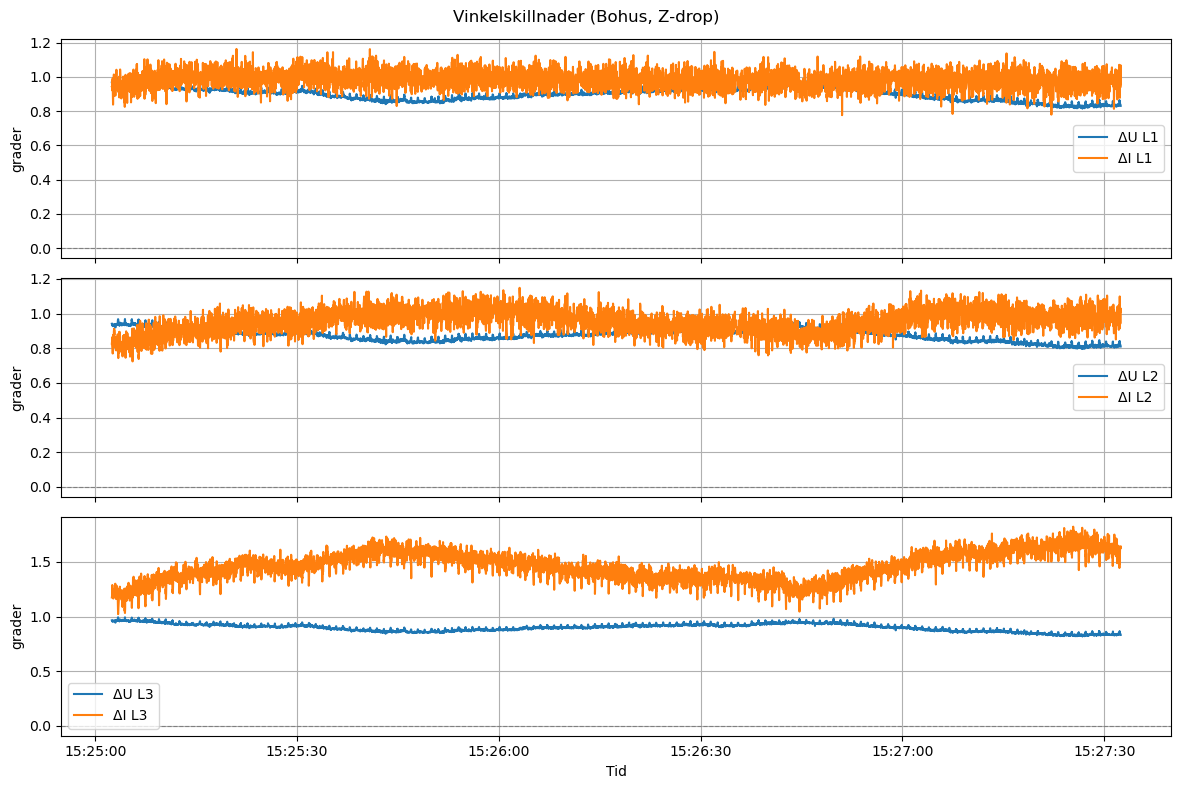

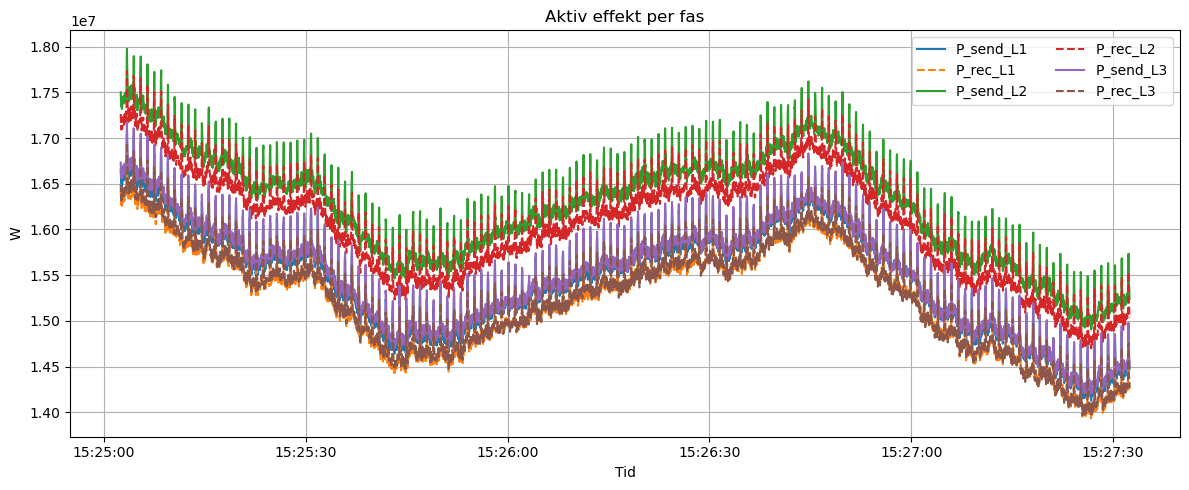

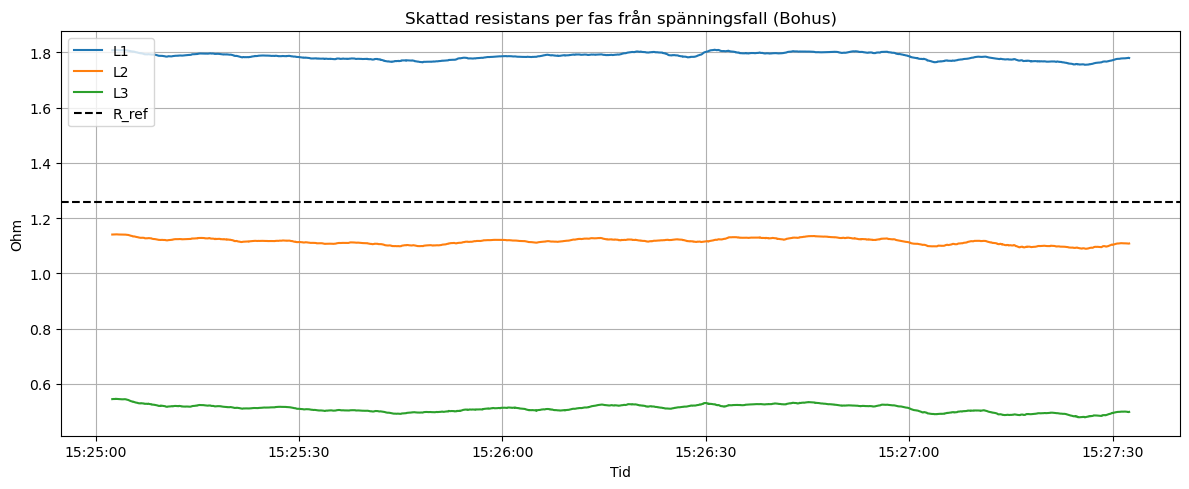

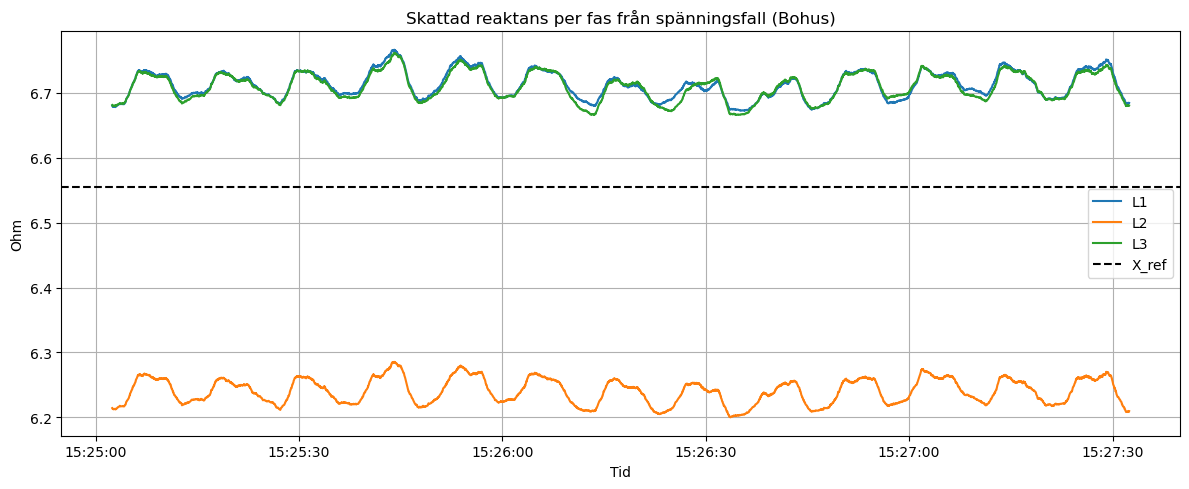

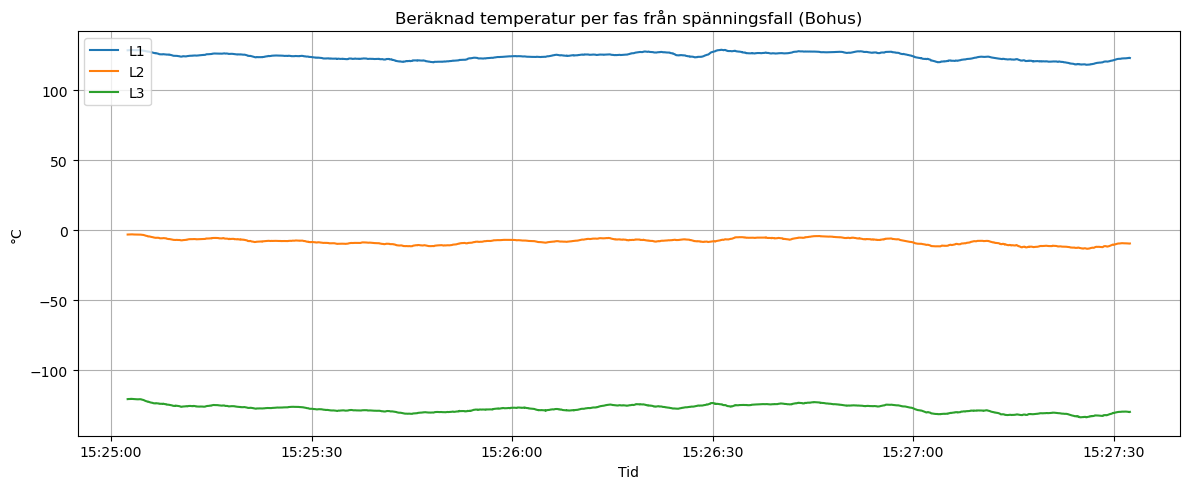

In [1]:
# ============================================================
# BACK TO BASICS: SPÄNNINGSFALL -> IMPEDANS -> RESISTANS -> TEMPERATUR
# Komplett Jupyter-cell
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# FILVÄGAR OCH BLADNAMN
# ============================================================

send_file = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx")
rec_file  = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx")

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", send_file.exists())
print("rec finns :", rec_file.exists())

# ============================================================
# MODELLVAL FRÅN OLSSON
# ============================================================

MODEL = "Bohus"   # byt till "Gota" om du vill testa

MODELS = {
    "Bohus": {
        "length_km": 17.25,
        "RAC_ohm_per_km": 0.0729,
        "alpha": 0.00403,
        "T_ref_C": 20.0,
        "X_ohm_per_km": 0.38,
    },
    "Gota": {
        "length_km": 21.95,
        "RAC_ohm_per_km": 0.0348,
        "alpha": 0.00403,
        "T_ref_C": 20.0,
        "X_ohm_per_km": 0.38,
    },
}

model = MODELS[MODEL]
R_ref = model["RAC_ohm_per_km"] * model["length_km"]
X_ref = model["X_ohm_per_km"] * model["length_km"]
alpha = model["alpha"]
T_ref = model["T_ref_C"]

print(f"\nVald modell: {MODEL}")
print(f"R_ref = {R_ref:.6f} Ω")
print(f"X_ref = {X_ref:.6f} Ω")
print(f"alpha = {alpha:.5f} 1/K")
print(f"T_ref = {T_ref:.1f} °C")

# ============================================================
# PARAMETRAR FÖR UTRÄKNING
# ============================================================

invert_receiver_current = True

# glidande medelvärde innan kvoten tas
smooth_seconds = 2.0     # testa gärna 1.0, 2.0, 5.0

# minimiström för att undvika division med nästan noll
min_current_A = 50.0

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna(how="all")
    T["Parameter"] = T["Parameter"].astype(str).str.strip()
    T["ID"] = T["ID"].astype(str).str.strip()
    return T

def read_data_table_safe(filename, sheetname):
    D = pd.read_excel(filename, sheet_name=sheetname, header=None)
    D = D.iloc[:, :3].copy()
    D.columns = ["Timestamp", "ID", "Value"]
    D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
    D["ID"] = D["ID"].astype(str).str.strip()
    D["Value"] = (
        D["Value"]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    D["Value"] = pd.to_numeric(D["Value"], errors="coerce")
    D = D.dropna(subset=["Timestamp"])
    return D

def complex_from_mag_ang(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def rolling_complex_mean(z, window):
    z_re = pd.Series(np.real(z), index=z.index).rolling(window=window, center=True, min_periods=1).mean()
    z_im = pd.Series(np.imag(z), index=z.index).rolling(window=window, center=True, min_periods=1).mean()
    return z_re + 1j * z_im

# ============================================================
# 1. LÄS OCH MAPPA DATA
# ============================================================

keyS = read_key_table_safe(send_file, keyS_sheet)
keyR = read_key_table_safe(rec_file, keyR_sheet)

send = read_data_table_safe(send_file, dataS_sheet)
rec  = read_data_table_safe(rec_file, dataR_sheet)

print("\nRådata:")
print("send rows:", len(send), "rec rows:", len(rec))
print("unika send timestamps:", send["Timestamp"].nunique())
print("unika rec timestamps :", rec["Timestamp"].nunique())

send = send.merge(keyS, on="ID", how="inner")
rec  = rec.merge(keyR, on="ID", how="inner")

print("\nEfter mappning:")
print("send rows:", len(send), "rec rows:", len(rec))
print("unika parametrar send:", send["Parameter"].nunique())
print("unika parametrar rec :", rec["Parameter"].nunique())

# ============================================================
# 2. PIVOTERA MED EXAKTA TIMESTAMPS
# ============================================================

wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

wideS = wideS.add_suffix("_S").sort_index()
wideR = wideR.add_suffix("_R").sort_index()

df_joined = wideS.join(wideR, how="inner").copy()

print("\nExakt join:")
print("joined rows:", len(df_joined))
print("start:", df_joined.index.min())
print("slut :", df_joined.index.max())

required_cols = []
for ph in ["L1", "L2", "L3"]:
    required_cols += [
        f"U{ph}MAG_S", f"U{ph}ANG_S", f"U{ph}MAG_R", f"U{ph}ANG_R",
        f"I{ph}MAG_S", f"I{ph}ANG_S", f"I{ph}MAG_R", f"I{ph}ANG_R",
    ]

missing = [c for c in required_cols if c not in df_joined.columns]
if missing:
    raise ValueError(f"Saknade kolumner: {missing}")

df_joined = df_joined.dropna(subset=required_cols).copy()
print("rows after dropna(required):", len(df_joined))

# ============================================================
# 3. BERÄKNA SAMPLINGSFREKVENS OCH GLIDFÖNSTER
# ============================================================

dt = df_joined.index.to_series().diff().dropna().dt.total_seconds()
fs = 1.0 / dt.median()
smooth_window = int(round(smooth_seconds * fs))

print("\nSampling:")
print("fs =", fs, "Hz")
print("smooth_window =", smooth_window, "samples")

# ============================================================
# 4. BYGG KOMPLEXA STORHETER OCH BERÄKNA IMPEDANS DIREKT
# ============================================================

out = pd.DataFrame(index=df_joined.index)
summary_rows = []

for ph in ["L1", "L2", "L3"]:
    Vs = complex_from_mag_ang(df_joined[f"U{ph}MAG_S"], df_joined[f"U{ph}ANG_S"])
    Vr = complex_from_mag_ang(df_joined[f"U{ph}MAG_R"], df_joined[f"U{ph}ANG_R"])

    Is = complex_from_mag_ang(df_joined[f"I{ph}MAG_S"], df_joined[f"I{ph}ANG_S"])
    Ir = complex_from_mag_ang(df_joined[f"I{ph}MAG_R"], df_joined[f"I{ph}ANG_R"])

    if invert_receiver_current:
        Ir = -Ir

    # Spänningsfall och medelström
    dV = Vs - Vr
    I_avg = 0.5 * (Is + Ir)

    # Glidande medelvärde på komplexa signaler innan kvoten
    dV_smooth = rolling_complex_mean(pd.Series(dV, index=df_joined.index), smooth_window)
    I_avg_smooth = rolling_complex_mean(pd.Series(I_avg, index=df_joined.index), smooth_window)

    # Skydd mot för små strömmar
    I_abs = np.abs(I_avg_smooth)
    valid = I_abs > min_current_A

    Z_est = pd.Series(np.nan + 1j*np.nan, index=df_joined.index, dtype=complex)
    Z_est.loc[valid] = dV_smooth.loc[valid] / I_avg_smooth.loc[valid]

    R_est = np.real(Z_est)
    X_est = np.imag(Z_est)

    T_est = ((R_est / R_ref) - 1.0) / alpha + T_ref

    # effekt för referens
    P_send = np.real(Vs * np.conj(Is))
    P_rec  = np.real(Vr * np.conj(Ir))

    dU = wrap_angle_deg(df_joined[f"U{ph}ANG_S"] - df_joined[f"U{ph}ANG_R"])
    dI = wrap_angle_deg(df_joined[f"I{ph}ANG_S"] - (df_joined[f"I{ph}ANG_R"] + (180.0 if invert_receiver_current else 0.0)))

    out[f"P_send_{ph}"] = P_send
    out[f"P_rec_{ph}"] = P_rec
    out[f"ΔU_deg_{ph}"] = dU
    out[f"ΔI_deg_{ph}"] = dI
    out[f"R_{ph}"] = R_est
    out[f"X_{ph}"] = X_est
    out[f"T_{ph}"] = T_est

    summary_rows.append({
        "Phase": ph,
        "Model": MODEL,
        "R_ref_Ohm": R_ref,
        "X_ref_Ohm": X_ref,
        "R_mean_Ohm": np.nanmean(R_est),
        "R_std_Ohm": np.nanstd(R_est),
        "X_mean_Ohm": np.nanmean(X_est),
        "X_std_Ohm": np.nanstd(X_est),
        "T_mean_C": np.nanmean(T_est),
        "T_std_C": np.nanstd(T_est),
        "dU_mean_deg": np.nanmean(dU),
        "dI_mean_deg": np.nanmean(dI),
        "P_send_mean_W": np.nanmean(P_send),
        "P_rec_mean_W": np.nanmean(P_rec),
    })

summary_df = pd.DataFrame(summary_rows)

print("\n=== Summary ===")
print(summary_df)

# ============================================================
# 5. SPARA RESULTAT
# ============================================================

VERSION = "bohus_v03_delta_u"   # <-- ändra bara denna rad nästa gång

output_dir = send_file.parent / VERSION
output_dir.mkdir(parents=True, exist_ok=True)

df_joined.reset_index().to_excel(output_dir / "df_joined_Zdrop.xlsx", index=False)
out.reset_index().to_excel(output_dir / "results_Zdrop.xlsx", index=False)
summary_df.to_excel(output_dir / "summary_Zdrop.xlsx", index=False)
summary_df.to_csv(output_dir / "summary_Zdrop.csv", index=False)

print("\nSparat till:", output_dir)


# ============================================================
# 6. PLOTTAR
# ============================================================

# Vinkelkontroll
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out.index, out[f"ΔU_deg_{ph}"], label=f"ΔU {ph}")
    axs[i].plot(out.index, out[f"ΔI_deg_{ph}"], label=f"ΔI {ph}")
    axs[i].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axs[i].grid(True)
    axs[i].legend()
    axs[i].set_ylabel("grader")
axs[-1].set_xlabel("Tid")
fig.suptitle(f"Vinkelskillnader ({MODEL}, Z-drop)")
fig.tight_layout()
fig.savefig(output_dir / "01_vinklar_Zdrop.png", dpi=200)
plt.show()

# Effekt
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"P_send_{ph}"], label=f"P_send_{ph}")
    ax.plot(out.index, out[f"P_rec_{ph}"], linestyle="--", label=f"P_rec_{ph}")
ax.grid(True)
ax.legend(ncol=2)
ax.set_title("Aktiv effekt per fas")
ax.set_ylabel("W")
ax.set_xlabel("Tid")
fig.tight_layout()
fig.savefig(output_dir / "02_effekt_Zdrop.png", dpi=200)
plt.show()

# Resistans
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"R_{ph}"], label=ph)
ax.axhline(R_ref, color="black", linestyle="--", label="R_ref")
ax.grid(True)
ax.legend()
ax.set_title(f"Skattad resistans per fas från spänningsfall ({MODEL})")
ax.set_ylabel("Ohm")
ax.set_xlabel("Tid")
fig.tight_layout()
fig.savefig(output_dir / "03_resistans_Zdrop.png", dpi=200)
plt.show()

# Reaktans
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"X_{ph}"], label=ph)
ax.axhline(X_ref, color="black", linestyle="--", label="X_ref")
ax.grid(True)
ax.legend()
ax.set_title(f"Skattad reaktans per fas från spänningsfall ({MODEL})")
ax.set_ylabel("Ohm")
ax.set_xlabel("Tid")
fig.tight_layout()
fig.savefig(output_dir / "04_reaktans_Zdrop.png", dpi=200)
plt.show()

# Temperatur
fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, out[f"T_{ph}"], label=ph)
ax.grid(True)
ax.legend()
ax.set_title(f"Beräknad temperatur per fas från spänningsfall ({MODEL})")
ax.set_ylabel("°C")
ax.set_xlabel("Tid")
fig.tight_layout()
fig.savefig(output_dir / "05_temperatur_Zdrop.png", dpi=200)
plt.show()